# Project 2 - Deliverable 1

**Dependent Variable:** After-tax income

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

df = pd.read_csv('CIS2022_PUMF_CLEANED.csv')

## 1. Analytical Context for Business Model

The objective of the model being created for the project aims to predict which factors lead to an increase in after tax income.

## 2. Remove Leaky and Irrelevant Variables (Domain Knowledge)

Removed certain columns that are used to calculate the target (ie earnings, (employment income)), irrelevant columns (ie Final Weight), derived from it (federal income tax) and columns that have been used to create it (logged version)

**Removed categories:**
- Income components (earnings, taxes, transfers, benefits, etc.) — these mathematically make up after-tax income
- Family-level income variables (EF- and CF- prefixed) — aggregated versions of the same income data
- Identifiers (household, person, family IDs) — no predictive meaning
- Engineered columns (_log, _sqrt, _ratio) — derived from the target or income components
- LICO/LIM/MBM flags — these are defined by income thresholds, so they are derived from the target

In [2]:
target = 'After-tax income'

# Columns to drop based on domain knowledge
drop_cols = [
    # Target itself
    'After-tax income',
    
    # Identifiers — no predictive value
    'Household identifier', 'Economic family identifier', 'Census family identifier',
    'Final weight',
    
    # Income components — these add up to after-tax income (leakage)
    'Earnings (employment income)', 'Investment income', 'Net self-employment income',
    'Other income', 'Support payments received', 'Support payments paid',
    'Scholarships and bursaries', 'Taxable capital gains',
    'Private retirement pensions (includes pension income splitting)',
    'Pension income splitting, amount given', 'Pension income splitting, amount received',
    'Old Age Security pension', 'CPP and QPP benefits',
    'Employment Insurance (EI) benefits', 'Social assistance benefits',
    'Workers\' compensation benefits', 'Child benefits',
    'Total provincial or territorial child benefits',
    'COVID-19 benefits', 'Federal COVID-19 benefits repayment',
    'Canada Workers Benefit', 'Other government transfers not included elsewhere',
    'Other government transfers', 'Federal refundable tax credits',
    'Guaranteed Income Supplement, Allowance and Allowance for survivor',
    'Federal GST/HST Credit (excludes prov./terr. sales tax credit)',
    'Government transfers, federal and provincial/territorial',
    'Provincial/territorial seniors supplements',
    
    # Tax variables — derived from income
    'Federal income tax', 'CPP and QPP contributions',
    'Contributions to Employment Insurance', 'Registered pension plan contributions',
    'RRSP withdrawals', 'Union dues (and other professional premiums)',
    'Child care expenses',
    
    # Income flags and thresholds — derived from income
    'Flag - After-tax income below LICO-AT', 'Flag - Before-tax income below LICO-BT',
    'Flag - After-tax income below the LIM-AT threshold',
    'Flag - Disposable income below MBM threshold (2018 base)',
    'Major source of income',
    
    # Relationship to income earner — tied to who earns most, not independent predictors
    'Flag - Major income earner in the economic family',
    'Flag - Economic family includes major income earner of household',
    'Relationship to major income earner in economic family, group',
    'Flag - Census family includes major income earner of household',
    'Relationship to major income earner in census family, group',
    'Major source of income for the economic family',
    
    # Family-level income variables (EF and CF prefixed columns)
] + [col for col in df.columns if col.startswith(('EF -', 'CF -'))]

# Engineered columns — derived from income variables
drop_cols += [col for col in df.columns if col.endswith(('_log', '_sqrt', '_ratio'))]
drop_cols += ['effective_tax_rate', 'is_early_career', 'is_rising_earnings', 
              'is_peak_earnings', 'is_pre_retirement']

# Keep only columns not in the drop list
candidates = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')


print(f"features kept for Mutual information:")
for col in candidates.columns:
    print(f"  - {col}")

features kept for Mutual information:
  - Province
  - Adjusted size of area of residence
  - Person's age group as of December 31 of refyear
  - Sex
  - Marital status
  - Flag - Person completed high school
  - Highest level of education of person, 2nd grouping
  - Flag - Person was employed during the reference year
  - Yearly summary of time worked during the refyear
  - Annual labour force status
  - Number of weeks unemployed during refyear
  - Flag - Person is a landed immigrant
  - Number of economic family members
  - Economic family type
  - Age group of oldest person in economic family
  - Age group of youngest person in economic family
  - Census family composition
  - Household composition
  - Type of dwelling
  - Ownership of dwelling
  - Condition of dwelling
  - Flag - Dwelling suitable, according to Nat. Occ. Standard
  - Flag - Mortgage on dwelling
  - Core housing need indicator
  - Food security - adult status (including marginally)
  - Flag - Visible minority statu

## 3. Drop Constant and Quasi-Constant Input Features



In [3]:
# Check for constant or quasi-constant features (99%+ same value)
quasi_constant_threshold = 0.99

quasi_constant_cols = []
for col in candidates.columns:
    top_freq = candidates[col].value_counts(normalize=True).iloc[0]
    if top_freq >= quasi_constant_threshold:
        quasi_constant_cols.append(col)

if quasi_constant_cols:
    print(f"Dropping {len(quasi_constant_cols)} quasi-constant feature(s): {quasi_constant_cols}")
    candidates = candidates.drop(columns=quasi_constant_cols)
else:
    print("No constant or quasi-constant features found.")

No constant or quasi-constant features found.


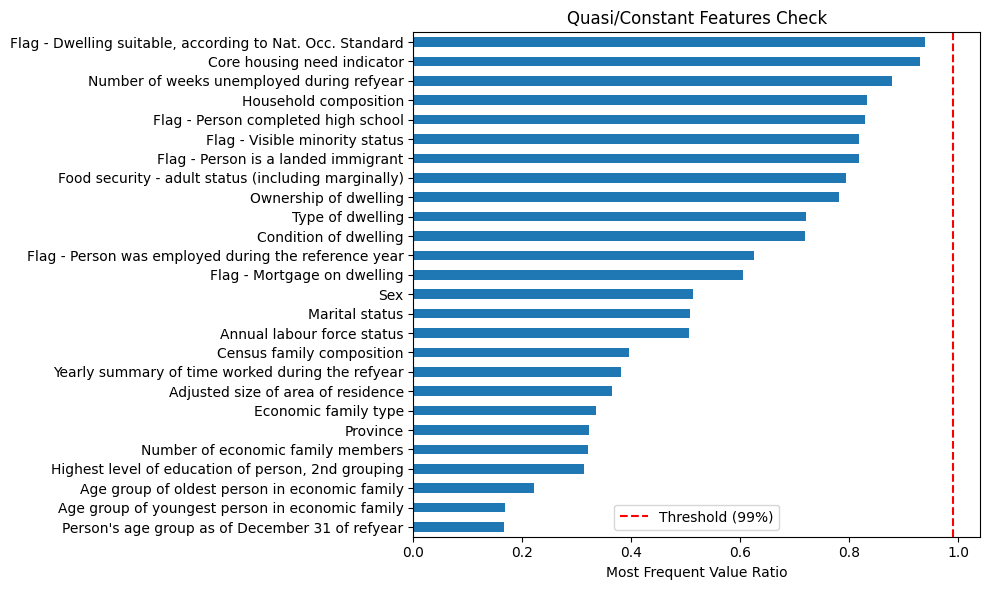

In [4]:
# Visualize the dominant value frequency for each feature
freq = candidates.apply(lambda col: col.value_counts(normalize=True).iloc[0]).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
freq.plot(kind='barh')
plt.axvline(x=quasi_constant_threshold, color='red', linestyle='--', label=f'Threshold ({quasi_constant_threshold:.0%})')
plt.xlabel('Most Frequent Value Ratio')
plt.title('Quasi/Constant Features Check')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Drop Highly Correlated (Redundant) Features

If two features are highly correlated with each other (above 0.8), they carry redundant information. We keep one and drop the other to reduce multicollinearity.

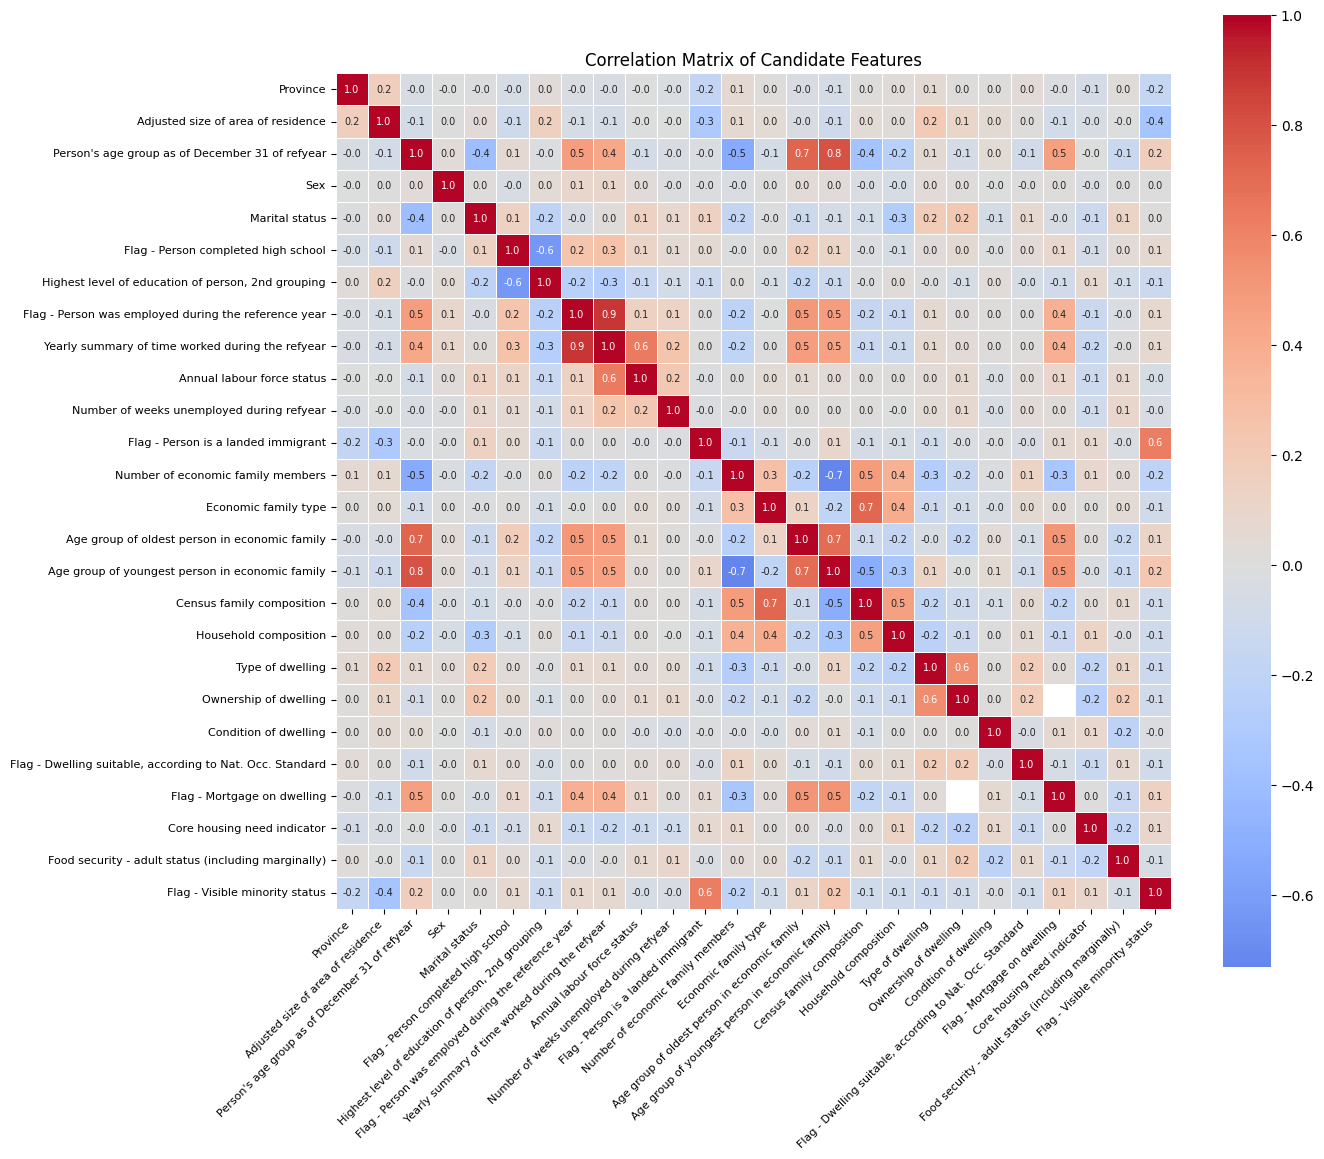

In [5]:
import seaborn as sns

corr_matrix = candidates.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7}, square=True)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Correlation Matrix of Candidate Features')
plt.tight_layout()
plt.show()

In [6]:
# Find highly correlated pairs and drop one from each pair
corr_threshold = 0.8

# Get upper triangle of correlation matrix (avoid counting pairs twice)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs above threshold
high_corr_pairs = []
to_drop = set()
for col in upper.columns:
    for row in upper.index:
        if abs(upper.loc[row, col]) >= corr_threshold:
            high_corr_pairs.append((row, col, upper.loc[row, col]))
            to_drop.add(col)

if high_corr_pairs:
    print("Highly correlated pairs (|r| >= 0.8):\n")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1}  <->  {f2}  (r = {r:.2f})")
    print(f"\nDropping: {list(to_drop)}")
    candidates = candidates.drop(columns=list(to_drop))
else:
    print("No highly correlated pairs found.")

print(f"\nRemaining features: {candidates.shape[1]}")

Highly correlated pairs (|r| >= 0.8):

  Flag - Person was employed during the reference year  <->  Yearly summary of time worked during the refyear  (r = 0.89)

Dropping: ['Yearly summary of time worked during the refyear']

Remaining features: 25


## 5. Mutual Information

Mutual information measures how much knowing a feature reduces uncertainty about the target. Unlike correlation, it captures non-linear relationships.

**Note on Chi-Square:** Chi-Square feature selection is used for classification problems (categorical target). Since our target (After-tax income) is continuous, this is a regression problem, so Chi-Square does not apply here. Mutual Information is the appropriate filter method for regression.

In [7]:
# Drop rows with missing values for MI calculation
mi_data = candidates.dropna()
y = df.loc[mi_data.index, target]

# Calculate mutual information scores
mi_scores = mutual_info_regression(mi_data, y, random_state=42)
mi_results = pd.Series(mi_scores, index=mi_data.columns).sort_values(ascending=False)

print("Mutual Information Scores:\n")
for feat, score in mi_results.items():
    print(f"  {feat:55s} {score:.4f}")

Mutual Information Scores:

  Person's age group as of December 31 of refyear         0.1994
  Annual labour force status                              0.1716
  Highest level of education of person, 2nd grouping      0.1240
  Flag - Person was employed during the reference year    0.1151
  Age group of youngest person in economic family         0.0828
  Marital status                                          0.0699
  Economic family type                                    0.0665
  Flag - Person completed high school                     0.0645
  Age group of oldest person in economic family           0.0519
  Census family composition                               0.0375
  Core housing need indicator                             0.0253
  Number of weeks unemployed during refyear               0.0246
  Province                                                0.0217
  Number of economic family members                       0.0216
  Flag - Mortgage on dwelling                             0.01

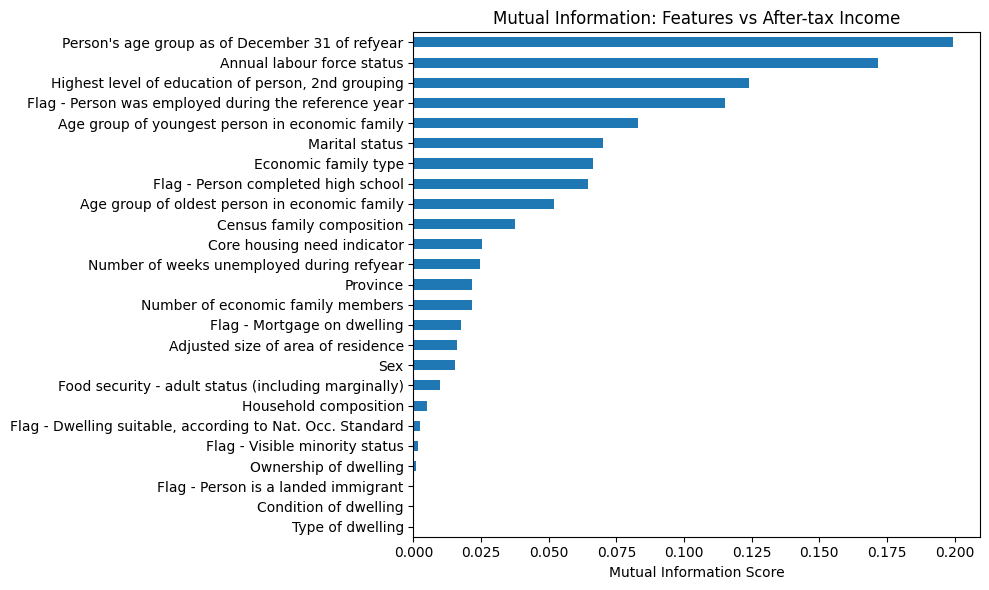

In [8]:
# Plot MI scores
plt.figure(figsize=(10, 6))
mi_results.plot(kind='barh')
plt.xlabel('Mutual Information Score')
plt.title('Mutual Information: Features vs After-tax Income')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Select Final Independent Variables

Based on the MI scores, we select features with a meaningful score (above a threshold). Features with very low MI contribute little to predicting after-tax income.

In [9]:
# Select features with MI score above threshold
threshold = 0.05
selected_features = mi_results[mi_results > threshold].index.tolist()

print(f"Selected {len(selected_features)} independent variables (MI > {threshold}):\n")
for feat in selected_features:
    print(f"  - {feat} (MI: {mi_results[feat]:.4f})")

# Final dataset
X = df[selected_features]
y = df[target]
print(f"\nFinal X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

Selected 9 independent variables (MI > 0.05):

  - Person's age group as of December 31 of refyear (MI: 0.1994)
  - Annual labour force status (MI: 0.1716)
  - Highest level of education of person, 2nd grouping (MI: 0.1240)
  - Flag - Person was employed during the reference year (MI: 0.1151)
  - Age group of youngest person in economic family (MI: 0.0828)
  - Marital status (MI: 0.0699)
  - Economic family type (MI: 0.0665)
  - Flag - Person completed high school (MI: 0.0645)
  - Age group of oldest person in economic family (MI: 0.0519)

Final X shape: (96302, 9)
Final y shape: (96302,)


## 7. Model Building (Baseline)

Train/test split: 80/20. All models use default hyperparameters — this is baseline performance before any tuning.

**Models:**
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Support Vector Regressor (SVR)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Drop rows with missing values
data = pd.concat([X, y], axis=1).dropna()
X_clean = data[selected_features]
y_clean = data[target]

print(f"Rows before dropping NaN: {X.shape[0]}")
print(f"Rows after dropping NaN:  {X_clean.shape[0]}")

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Rows before dropping NaN: 96302
Rows after dropping NaN:  56573

Training set: 45258 samples
Testing set:  11315 samples


In [11]:
# Define models with default parameters
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR()
}

# Train and evaluate each model
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    n = X_test.shape[0]
    p = X_test.shape[1]
    r2 = r2_score(y_test, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model': name,
        'R²': round(r2, 4),
        'Adjusted R²': round(adj_r2, 4),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2)
    })
    print(f"  R²={r2:.4f} | Adj R²={adj_r2:.4f} | RMSE={rmse:.2f} | MAE={mae:.2f}")

print("\nAll models trained.")

Training Linear Regression...
  R²=0.2248 | Adj R²=0.2241 | RMSE=40756.78 | MAE=22682.98
Training Decision Tree...
  R²=0.1552 | Adj R²=0.1546 | RMSE=42545.33 | MAE=23796.10
Training Random Forest...


  R²=0.2019 | Adj R²=0.2012 | RMSE=41354.51 | MAE=22874.83
Training SVR...


  R²=-0.0102 | Adj R²=-0.0110 | RMSE=46524.73 | MAE=28299.63

All models trained.


In [12]:
# Summary table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model      R²  Adjusted R²     RMSE      MAE
Linear Regression  0.2248       0.2241 40756.78 22682.98
    Decision Tree  0.1552       0.1546 42545.33 23796.10
    Random Forest  0.2019       0.2012 41354.51 22874.83
              SVR -0.0102      -0.0110 46524.73 28299.63
